# Player component and Predictive Box VPM forecasts

Evaluate next-map component forecasts, learned box weights, ablations, likelihood, and interval coverage.

This notebook is generated from immutable, hash-manifested artifacts. Any
counterfactual agent or composition result is predictive/associational,
not a causal estimate.

In [1]:
from pathlib import Path

SNAPSHOT = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\data\snapshots\vct_2023_2026_cutoff_2026-06-21_v2")
DEVELOPMENT = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full")
CONFIRMATION = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__2026-confirmation")
SCORING_V3 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v3")
SCORING_V2 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v2")
SCORING_V1 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots")
SCORING = SCORING_V3 if SCORING_V3.exists() else (SCORING_V2 if SCORING_V2.exists() else SCORING_V1)

print("snapshot:", SNAPSHOT)
print("development:", DEVELOPMENT if DEVELOPMENT.exists() else "not supplied")
print("confirmation:", CONFIRMATION if CONFIRMATION.exists() else "not available")
print("scoring:", SCORING if SCORING.exists() else "not available")

snapshot: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\data\snapshots\vct_2023_2026_cutoff_2026-06-21_v2
development: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full
confirmation: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__2026-confirmation
scoring: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v3


,ablation,component,observations,mae,mean_log_likelihood,interval80_coverage,extrapolated_rate
0,triple,__box_vpm__,23665,0.212193,-2.427332,0.323262,0.562561
1,two-way,__box_vpm__,23665,0.212196,-2.470376,0.320262,1.000000
2,additive,__box_vpm__,23665,0.212200,-2.620650,0.313712,1.000000
3,composition,__box_vpm__,23665,0.212203,-2.581904,0.315952,0.244919
4,player-only,__box_vpm__,23665,0.212260,-2.549466,0.319163,1.000000


lowest-MAE player ablation: triple


,value
ablation,triple
calibration_rows,12640
calibration_year,2025
component,__box_vpm__
raw_calibration_year_coverage,0.284177
scale,2.976173
scaled_all_development_coverage,0.821001
scaled_calibration_year_coverage,0.8
target_coverage,0.8


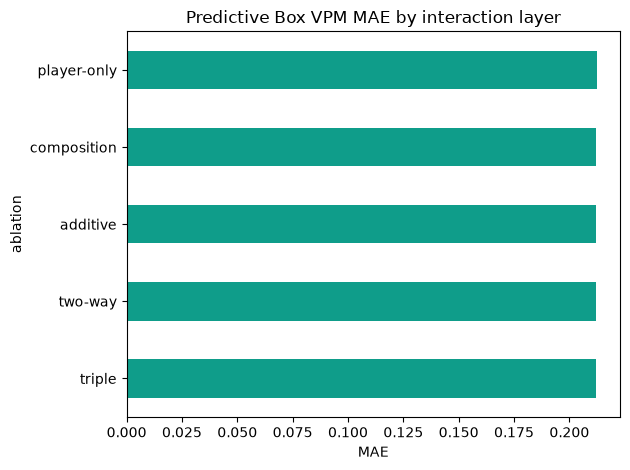

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

metrics = pd.read_parquet(DEVELOPMENT / "metrics" / "player_ablations.parquet")
predictions = pd.read_parquet(DEVELOPMENT / "predictions" / "player_oof.parquet")
box = metrics.loc[metrics["component"] == "__box_vpm__"].sort_values("mae")
display(box)
best = str(box.iloc[0]["ablation"])
print("lowest-MAE player ablation:", best)
calibration_path = SCORING / "player_uncertainty_calibration.json"
if calibration_path.exists():
    import json
    display(pd.Series(json.loads(calibration_path.read_text(encoding="utf-8")), name="value").to_frame())

ax = box.set_index("ablation")["mae"].sort_values().plot.barh(
    title="Predictive Box VPM MAE by interaction layer", color="#0f9d8a"
)
ax.set(xlabel="MAE", ylabel="ablation")
plt.tight_layout()
plt.show()

In [3]:
component_rows = metrics.loc[
    (metrics["ablation"] == best) & (metrics["component"] != "__box_vpm__")
].sort_values("mae")
display(component_rows)

selected = predictions.loc[predictions["ablation"] == best]
coverage = selected.groupby("component").agg(
    observations=("absolute_error", "size"),
    mae=("absolute_error", "mean"),
    interval80_coverage=("covered80", "mean"),
    mean_log_likelihood=("log_likelihood", "mean"),
)
display(coverage)

,ablation,component,observations,mae,mean_log_likelihood,interval80_coverage,extrapolated_rate
22,triple,first_duel_attempt_rate,23760,0.081863,0.792831,0.900589,0.562879
32,triple,kast,19950,0.090536,0.690134,0.897995,0.549975
17,triple,dpr,23760,0.101817,0.535726,0.923695,0.562879
12,triple,apr,23760,0.107035,0.465577,0.937626,0.562879
37,triple,kpr,23760,0.173860,-0.003710,0.934133,0.562879
28,triple,first_duel_win_rate,20662,0.240572,-0.290260,0.896041,0.548640
7,triple,adr,21370,27.590516,-5.041687,0.916004,0.547356


,observations,mae,interval80_coverage,mean_log_likelihood
component,,,,
__box_vpm__,23665,0.212193,0.323262,-2.427332
adr,21370,27.590516,0.916004,-5.041687
apr,23760,0.107035,0.937626,0.465577
dpr,23760,0.101817,0.923695,0.535726
first_duel_attempt_rate,23760,0.081863,0.900589,0.792831
first_duel_win_rate,20662,0.240572,0.896041,-0.290260
kast,19950,0.090536,0.897995,0.690134
kpr,23760,0.173860,0.934133,-0.003710


The player performance score is retained independently of a causal
contribution interpretation. A lineup-result contribution update is
promoted only if it adds transfer and roster-change forecast lift.